<section dir="rtl" lang="ar" style="text-align: right;">
  <h3>1. إعداد بيئة العمل وتثبيت المكتبات</h3>
  <p>
    تقوم هذه الخلية بتثبيت المكتبات الأساسية اللازمة لبناء خط معالجة المشروع، وتشمل مكتبات نماذج تمثيل الجمل، وأدوات النماذج التحويلية، وBERTopic، وتقليل الأبعاد، والتجميع، ومعالجة النصوص.
  </p>
</section>

In [ ]:
!pip install -q sentence-transformers datasets accelerate transformers bertopic umap-learn hdbscan nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 9.6 MB/s eta 0:00:00


<section dir="rtl" lang="ar" style="text-align: right;">
  <h3>2. تهيئة بيئة المشروع والمسارات الأساسية</h3>
  <p>
    تقوم هذه الخلية بربط بيئة العمل مع Google Drive، واستيراد المكتبات المطلوبة، وضبط قيمة ثابتة للعشوائية لضمان قابلية إعادة النتائج، ثم تحديد مسارات البيانات والنماذج والتحقق من توفر الملفات الأساسية وبيئة المعالجة الرسومية.
  </p>
</section>

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import json
import random
import re
import numpy as np
import pandas as pd
import torch

from datasets import Dataset
from sentence_transformers import SentenceTransformer, losses
from sentence_transformers.evaluation import InformationRetrievalEvaluator
from sentence_transformers.trainer import SentenceTransformerTrainer
from sentence_transformers.training_args import SentenceTransformerTrainingArguments, BatchSamplers

RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

PROJECT_ROOT = Path("/content/drive/MyDrive/semester project/news_comment_topic_system")

if not PROJECT_ROOT.exists():
    PROJECT_ROOT = Path("/content/gdrive/MyDrive/semester project/news_comment_topic_system")

PAIR_DIR = PROJECT_ROOT / "training_data/v7_raw_pair_mining_20260428_232654"

TRAIN_PAIRS_PATH = PAIR_DIR / "train_stage1_pairs_v7_raw_large_balanced_1p5M.csv"
VAL_PAIRS_PATH = PAIR_DIR / "val_stage1_pairs_v7_raw_large_balanced_30k.csv"
PAIR_METADATA_PATH = PAIR_DIR / "v7_raw_large_balanced_pair_mining_metadata.json"

MODELS_DIR = PROJECT_ROOT / "models"

RUN_NAME = "v9_bge_base_en_largepairs_1p5M_seq256"
OUTPUT_DIR = MODELS_DIR / RUN_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("TRAIN_PAIRS_PATH exists:", TRAIN_PAIRS_PATH.exists())
print("VAL_PAIRS_PATH exists:", VAL_PAIRS_PATH.exists())
print("PAIR_METADATA_PATH exists:", PAIR_METADATA_PATH.exists())
print("OUTPUT_DIR:", OUTPUT_DIR)
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU RAM GB:", round(torch.cuda.get_device_properties(0).total_memory / (1024**3), 2))

Mounted at /content/drive


/tmp/ipykernel_4871/3161946429.py:13: DeprecationWarning: Importing from 'sentence_transformers.losses' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.losses' instead.
  from sentence_transformers import SentenceTransformer, losses
/tmp/ipykernel_4871/3161946429.py:14: DeprecationWarning: Importing from 'sentence_transformers.evaluation' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.evaluation' instead.
  from sentence_transformers.evaluation import InformationRetrievalEvaluator
/tmp/ipykernel_4871/3161946429.py:15: DeprecationWarning: Importing from 'sentence_transformers.trainer' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.trainer' instead.
  from sentence_transformers.trainer import SentenceTransformerTrainer
/tmp/ipykernel_4871/3161946429.py:16: DeprecationWarning: Importing from 'sentence_tr

PROJECT_ROOT: /content/drive/MyDrive/semester project/news_comment_topic_system
TRAIN_PAIRS_PATH exists: True
VAL_PAIRS_PATH exists: True
PAIR_METADATA_PATH exists: True
OUTPUT_DIR: /content/drive/MyDrive/semester project/news_comment_topic_system/models/v9_bge_base_en_largepairs_1p5M_seq256
CUDA: True
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
GPU RAM GB: 94.97


<section dir="rtl" lang="ar" style="text-align: right;">
  <h3>3. تحميل أزواج التدريب والتحقق وفحصها</h3>
  <p>
    تقوم هذه الخلية بقراءة أزواج التعليقات المستخدمة في تدريب النموذج والتحقق منه، ثم تحويل قيمة التشابه إلى صيغة رقمية، وإزالة السجلات غير المكتملة، وعرض حجم البيانات وعينات أولية منها مع إحصاءات التشابه للتأكد من سلامة البيانات قبل بدء التدريب.
  </p>
</section>

In [ ]:
train_pairs = pd.read_csv(
    TRAIN_PAIRS_PATH,
    dtype={
        "post_id_true": str,
        "text_a": str,
        "text_b": str,
        "split": str,
    },
    low_memory=False
)

val_pairs = pd.read_csv(
    VAL_PAIRS_PATH,
    dtype={
        "post_id_true": str,
        "text_a": str,
        "text_b": str,
        "split": str,
    },
    low_memory=False
)

train_pairs["similarity"] = train_pairs["similarity"].astype(float)
val_pairs["similarity"] = val_pairs["similarity"].astype(float)

train_pairs = train_pairs.dropna(subset=["text_a", "text_b"]).reset_index(drop=True)
val_pairs = val_pairs.dropna(subset=["text_a", "text_b"]).reset_index(drop=True)

print("Train pairs:", train_pairs.shape)
print("Val pairs:", val_pairs.shape)

display(train_pairs.head())
display(val_pairs.head())

print("\nTrain similarity:")
display(train_pairs["similarity"].describe())

print("\nVal similarity:")
display(val_pairs["similarity"].describe())

Train pairs: (1500000, 5)
Val pairs: (30000, 5)


,post_id_true,text_a,text_b,similarity,split
0,10154675557324067,What a waste of their appearance. Their oath i...,Looks like contempt. Apparently these civil se...,0.627721,train
1,1644964158933163,Don't understand how you can sue someone for b...,"Truthfully, I wouldn't care if Trump blocked m...",0.616384,train
2,10155065604589087,Dumbp the delusional pumpkin-headed buffoon in...,He says crap like that because he's too stupid...,0.661328,train
3,1516953038342031,"Well, i think that most positions held by Demo...",This whole thing hangs on majority and VP... c...,0.605214,train
4,10155608269114060,Hahahaha this guy is savage!!! He says what ev...,Have you ever heard anything more sexist ..it ...,0.469634,train


,post_id_true,text_a,text_b,similarity,split
0,10155066871714087,Get a life. There has been no collusion with R...,"ACTIONS SPEAK- AND, “official” responses and e...",0.492279,val
1,10155631596788010,Love Disneyland but I am not renewing my 5 del...,Go on the big rides ( Splash Mountain; Space M...,0.567880,val
2,10154662125842297,I am a liberal and an intellectual but I do no...,As much as I like her advocacy and legislating...,0.643913,val
3,10155662446271336,What common cause? The Russians want to suppor...,NO...it is NOT in our best interest to work wi...,0.567721,val
4,10154662221057297,His every cell has caused civil war in our eve...,He's just completely ignorant of any facts! If...,0.520073,val



Train similarity:


,similarity
count,1.500000e+06
mean,6.024184e-01
std,6.472059e-02
min,4.500003e-01
25%,5.637642e-01
50%,5.940013e-01
75%,6.389512e-01
max,8.999673e-01



Val similarity:


,similarity
count,30000.000000
mean,0.607473
std,0.071215
min,0.450041
25%,0.563961
50%,0.596498
75%,0.646003
max,0.899481


<section dir="rtl" lang="ar" style="text-align: right;">
  <h3>4. تحميل النموذج الأساسي وإعداد التدريب الكامل</h3>
  <p>
    تقوم هذه الخلية بتحميل نموذج تمثيل الجمل الأساسي، وتحديد طول النص الأقصى، واختيار وحدة المعالجة المناسبة، ثم تفعيل تدريب جميع معاملات النموذج وحساب عدد المعاملات الكلي والقابل للتدريب للتأكد من أن التدريب سيتم بصورة كاملة.
  </p>
</section>

In [ ]:
BASE_MODEL_NAME = "BAAI/bge-base-en-v1.5"
MAX_SEQ_LENGTH = 256

device = "cuda" if torch.cuda.is_available() else "cpu"

model = SentenceTransformer(BASE_MODEL_NAME, device=device)
model.max_seq_length = MAX_SEQ_LENGTH

for param in model.parameters():
    param.requires_grad = True

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Base model:", BASE_MODEL_NAME)
print("Device:", device)
print("Max sequence length:", model.max_seq_length)
print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)
print("Trainable ratio:", round(trainable_params / total_params * 100, 2), "%")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Base model: BAAI/bge-base-en-v1.5
Device: cuda
Max sequence length: 256
Total parameters: 109482240
Trainable parameters: 109482240
Trainable ratio: 100.0 %


<section dir="rtl" lang="ar" style="text-align: right;">
  <h3>5. تحويل أزواج التعليقات إلى صيغة بيانات التدريب</h3>
  <p>
    تقوم هذه الخلية بتحويل أزواج التعليقات من جداول Pandas إلى صيغة Dataset المناسبة للتدريب، مع إعادة تسمية أعمدة النصوص إلى أسماء موحدة يستخدمها نموذج تمثيل الجمل أثناء عملية التعلم.
  </p>
</section>

In [ ]:
train_dataset = Dataset.from_pandas(
    train_pairs[["text_a", "text_b"]].rename(
        columns={"text_a": "sentence1", "text_b": "sentence2"}
    ),
    preserve_index=False
)

val_dataset = Dataset.from_pandas(
    val_pairs[["text_a", "text_b"]].rename(
        columns={"text_a": "sentence1", "text_b": "sentence2"}
    ),
    preserve_index=False
)

print(train_dataset)
print(val_dataset)
print(train_dataset[0])

Dataset({
    features: ['sentence1', 'sentence2'],
    num_rows: 1500000
})
Dataset({
    features: ['sentence1', 'sentence2'],
    num_rows: 30000
})
{'sentence1': 'What a waste of their appearance. Their oath is to the Constitution not to DT. Sleazy two more men as well as Rosenstein. They all need to to be dumped. No reason they could not answer question. I call BS on them. Smart questioners Angus King and our Senator Kamala Harris. Kudos to them for calling out these yokels.', 'sentence2': "Looks like contempt. Apparently these civil servants do not operate within the parameters of their oaths and the law. They don't answer to the representatives of the American people, just to one person. The Republic has been pushed aside for the dictatorship."}


<section dir="rtl" lang="ar" style="text-align: right;">
  <h3>6. إعداد مجموعة التقييم باسترجاع المعلومات</h3>
  <p>
    تقوم هذه الخلية باختيار عينة من أزواج التحقق وبناء مكوّنات تقييم الاسترجاع، حيث يُستخدم النص الأول كاستعلام والنص الثاني كوثيقة صحيحة مقابلة له، ثم يتم إنشاء مقيّم يقيس قدرة النموذج على استرجاع التعليق الدلالي الصحيح ضمن مجموعة المرشحين.
  </p>
</section>

In [ ]:
EVAL_SIZE = 5000

eval_pairs = val_pairs.sample(
    n=min(EVAL_SIZE, len(val_pairs)),
    random_state=RANDOM_STATE
).reset_index(drop=True)

queries = {}
corpus = {}
relevant_docs = {}

for i, row in eval_pairs.iterrows():
    qid = f"q{i}"
    cid = f"c{i}"

    queries[qid] = row["text_a"]
    corpus[cid] = row["text_b"]
    relevant_docs[qid] = {cid}

ir_evaluator = InformationRetrievalEvaluator(
    queries=queries,
    corpus=corpus,
    relevant_docs=relevant_docs,
    name="val_ir_v9_bge",
    show_progress_bar=True,
    accuracy_at_k=[1, 3, 5, 10],
    precision_recall_at_k=[1, 3, 5, 10],
    mrr_at_k=[10],
    ndcg_at_k=[10],
    map_at_k=[100],
)

print("Evaluator queries:", len(queries))
print("Evaluator corpus:", len(corpus))

Evaluator queries: 5000
Evaluator corpus: 5000


<section dir="rtl" lang="ar" style="text-align: right;">
  <h3>7. تحديد دالة الخسارة المستخدمة في التدريب</h3>
  <p>
    تقوم هذه الخلية بإنشاء دالة الخسارة المعتمدة في تدريب نموذج تمثيل الجمل، بحيث يتعلم النموذج تقريب أزواج التعليقات المتشابهة دلاليًا، وفي المقابل إبعاد الأزواج غير المتطابقة داخل نفس دفعة التدريب.
  </p>
</section>

In [ ]:
train_loss = losses.MultipleNegativesRankingLoss(model)

print("Loss:", train_loss)

Loss: MultipleNegativesRankingLoss(
  (model): SentenceTransformer(
    (0): Transformer({'transformer_task': 'feature-extraction', 'modality_config': {'text': {'method': 'forward', 'method_output_name': 'last_hidden_state'}}, 'module_output_name': 'token_embeddings', 'architecture': 'BertModel'})
    (1): Pooling({'embedding_dimension': 768, 'pooling_mode': 'cls', 'include_prompt': True})
    (2): Normalize({})
  )
)


<section dir="rtl" lang="ar" style="text-align: right;">
  <h3>8. ضبط معاملات التدريب وحفظ أفضل نموذج</h3>
  <p>
    تقوم هذه الخلية بتحديد إعدادات تدريب النموذج، مثل عدد الدورات، حجم الدفعة، معدل التعلم، تنظيم الأوزان، نوع الدقة العددية، وآلية أخذ العينات داخل الدفعات. كما تضبط التقييم والحفظ الدوري للنموذج، مع اختيار أفضل نسخة اعتمادًا على أقل قيمة خسارة في بيانات التحقق.
  </p>
</section>

In [ ]:
from sentence_transformers.training_args import SentenceTransformerTrainingArguments, BatchSamplers

training_args = SentenceTransformerTrainingArguments(
    output_dir=str(OUTPUT_DIR),

    num_train_epochs=10,

    per_device_train_batch_size=128,
    per_device_eval_batch_size=128,

    learning_rate=1e-5,
    warmup_steps=0.10,
    weight_decay=0.01,

    bf16=True,
    fp16=False,

    batch_sampler=BatchSamplers.NO_DUPLICATES,

    logging_steps=200,

    eval_strategy="steps",
    eval_steps=2000,

    save_strategy="steps",
    save_steps=2000,
    save_total_limit=3,

    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    run_name=RUN_NAME,
    seed=RANDOM_STATE,

    dataloader_num_workers=2,

    report_to="none"
)

print(training_args)

SentenceTransformerTrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
batch_sampler=BatchSamplers.NO_DUPLICATES,
bf16=True,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=2,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=False,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=2000,
eva

<section dir="rtl" lang="ar" style="text-align: right;">
  <h3>9. إنشاء مدرّب النموذج وتفعيل الإيقاف المبكر</h3>
  <p>
    تقوم هذه الخلية بإنشاء كائن التدريب الذي يجمع النموذج، وإعدادات التدريب، وبيانات التدريب والتحقق، ودالة الخسارة، ومقيّم الاسترجاع. كما تضيف آلية الإيقاف المبكر لإيقاف التدريب عند عدم تحسن أداء النموذج على بيانات التحقق، مما يساعد على تقليل خطر فرط التعلّم وحفظ أفضل نسخة ممكنة.
  </p>
</section>

In [ ]:
from sentence_transformers.trainer import SentenceTransformerTrainer
from transformers import EarlyStoppingCallback

trainer = SentenceTransformerTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    loss=train_loss,
    evaluator=ir_evaluator,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=3,
            early_stopping_threshold=0.0
        )
    ]
)

print("Trainer is ready with early stopping.")

Trainer is ready with early stopping.


<section dir="rtl" lang="ar" style="text-align: right;">
  <h3>10. استكمال تدريب النموذج من نقطة حفظ سابقة</h3>
  <p>
    تقوم هذه الخلية باستكمال عملية التدريب من نقطة حفظ محددة بدل البدء من الصفر، مما يسمح بمتابعة التدريب بعد توقف سابق مع الحفاظ على حالة النموذج وإعدادات التدريب المرتبطة بتلك المرحلة.
  </p>
</section>

In [ ]:
train_result = trainer.train(
    resume_from_checkpoint=str(OUTPUT_DIR / "checkpoint-16000")
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Step,Training Loss,Validation Loss,Val Ir V9 Bge Cosine Accuracy@1,Val Ir V9 Bge Cosine Accuracy@3,Val Ir V9 Bge Cosine Accuracy@5,Val Ir V9 Bge Cosine Accuracy@10,Val Ir V9 Bge Cosine Precision@1,Val Ir V9 Bge Cosine Precision@3,Val Ir V9 Bge Cosine Precision@5,Val Ir V9 Bge Cosine Precision@10,Val Ir V9 Bge Cosine Recall@1,Val Ir V9 Bge Cosine Recall@3,Val Ir V9 Bge Cosine Recall@5,Val Ir V9 Bge Cosine Recall@10,Val Ir V9 Bge Cosine Ndcg@10,Val Ir V9 Bge Cosine Mrr@10,Val Ir V9 Bge Cosine Map@100
18000,0.995831,1.238785,0.156800,0.307400,0.396600,0.524800,0.156800,0.102467,0.079320,0.052480,0.156800,0.307400,0.396600,0.524800,0.322161,0.259599,0.273032
20000,0.975281,1.242926,0.158600,0.308000,0.396000,0.524200,0.158600,0.102667,0.079200,0.052420,0.158600,0.308000,0.396000,0.524200,0.321838,0.259410,0.272856
22000,0.942439,1.244570,0.156600,0.305800,0.397800,0.529800,0.156600,0.101933,0.079560,0.052980,0.156600,0.305800,0.397800,0.529800,0.323313,0.259627,0.272714


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

Corpus Chunks:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/157 [00:00<?, ?it/s]

...

Corpus Chunks:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/157 [00:00<?, ?it/s]

Corpus Chunks: 100%|██████████| 1/1 [00:00<00:00,  1.09it/s]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

<section dir="rtl" lang="ar" style="text-align: right;">
  <h3>11. قراءة سجل التدريب واستخراج أفضل نقطة حفظ</h3>
  <p>
    تقوم هذه الخلية بقراءة ملف حالة التدريب، ثم تحويل سجل الخطوات إلى جدول قابل للتحليل. بعد ذلك تفصل سجلات التدريب عن سجلات التحقق، وتعرض عدد القياسات المسجلة، وأفضل نقطة حفظ، وأفضل قيمة خسارة تحقق، بهدف مراجعة مسار التدريب وتحديد النسخة الأفضل من النموذج.
  </p>
</section>

In [ ]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

trainer_state_files = list(OUTPUT_DIR.rglob("trainer_state.json"))

if not trainer_state_files:
    raise FileNotFoundError("No trainer_state.json found")

trainer_state_path = sorted(trainer_state_files)[-1]
print("Using:", trainer_state_path)

with open(trainer_state_path, "r", encoding="utf-8") as f:
    state = json.load(f)

log_df = pd.DataFrame(state["log_history"])

train_log = log_df.dropna(subset=["loss"]).copy()
eval_log = log_df.dropna(subset=["eval_loss"]).copy()

print("Training rows:", train_log.shape[0])
print("Evaluation rows:", eval_log.shape[0])
print("Best checkpoint:", state.get("best_model_checkpoint"))
print("Best eval loss:", state.get("best_metric"))

display(eval_log.tail())

Using: /content/drive/MyDrive/semester project/news_comment_topic_system/models/v9_bge_base_en_largepairs_1p5M_seq256/checkpoint-22000/trainer_state.json
Training rows: 110
Evaluation rows: 11
Best checkpoint: /content/drive/MyDrive/semester project/news_comment_topic_system/models/v9_bge_base_en_largepairs_1p5M_seq256/checkpoint-16000
Best eval loss: 1.2327957153320312


,epoch,grad_norm,learning_rate,loss,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second,eval_val_ir_v9_bge_cosine_accuracy@1,...,eval_val_ir_v9_bge_cosine_mrr@10,eval_val_ir_v9_bge_cosine_ndcg@10,eval_val_ir_v9_bge_cosine_precision@1,eval_val_ir_v9_bge_cosine_precision@10,eval_val_ir_v9_bge_cosine_precision@3,eval_val_ir_v9_bge_cosine_precision@5,eval_val_ir_v9_bge_cosine_recall@1,eval_val_ir_v9_bge_cosine_recall@10,eval_val_ir_v9_bge_cosine_recall@3,eval_val_ir_v9_bge_cosine_recall@5
76,1.194641,NaN,NaN,NaN,14000,1.240652,18.2997,1639.373,12.842,0.1572,...,0.258859,0.320112,0.1572,0.05182,0.103067,0.07892,0.1572,0.5182,0.3092,0.3946
87,1.365304,NaN,NaN,NaN,16000,1.232796,18.2834,1640.833,12.853,0.1560,...,0.259228,0.321964,0.1560,0.05252,0.103400,0.07912,0.1560,0.5252,0.3102,0.3956
98,1.535967,NaN,NaN,NaN,18000,1.238785,18.3453,1635.296,12.810,0.1568,...,0.259599,0.322161,0.1568,0.05248,0.102467,0.07932,0.1568,0.5248,0.3074,0.3966
109,1.706630,NaN,NaN,NaN,20000,1.242926,18.3094,1638.500,12.835,0.1586,...,0.259410,0.321838,0.1586,0.05242,0.102667,0.07920,0.1586,0.5242,0.3080,0.3960
120,1.877293,NaN,NaN,NaN,22000,1.244570,18.2910,1640.149,12.848,0.1566,...,0.259627,0.323313,0.1566,0.05298,0.101933,0.07956,0.1566,0.5298,0.3058,0.3978


<section dir="rtl" lang="ar" style="text-align: right;">
  <h3>12. رسم منحنى خسارة التدريب والتحقق</h3>
  <p>
    تقوم هذه الخلية برسم تغير خسارة التدريب وخسارة التحقق عبر خطوات التدريب، وذلك بهدف متابعة سلوك التعلم بصريًا، وتقدير مدى التحسن، ورصد أي إشارات محتملة على تدهور التحقق أو بدء فرط التعلّم.
  </p>
</section>

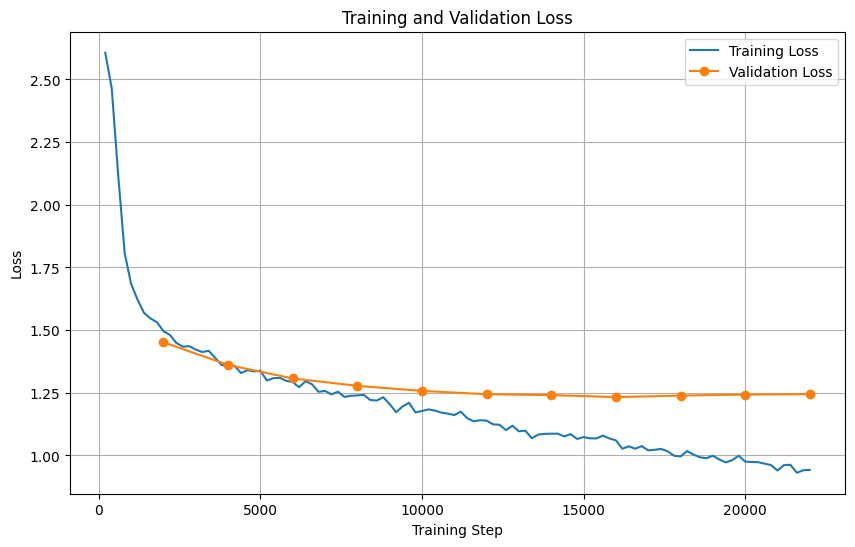

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(train_log["step"], train_log["loss"], label="Training Loss")
plt.plot(eval_log["step"], eval_log["eval_loss"], marker="o", label="Validation Loss")

plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.grid(True)
plt.legend()
plt.show()

<section dir="rtl" lang="ar" style="text-align: right;">
  <h3>13. رسم مؤشرات الدقة أثناء التحقق</h3>
  <p>
    تقوم هذه الخلية باستخراج أعمدة الدقة المسجلة أثناء التحقق، ثم رسم مؤشري Accuracy@1 وAccuracy@10 عبر خطوات التدريب. يساعد هذا الرسم على تقييم قدرة النموذج على استرجاع التعليق الصحيح ضمن أعلى النتائج، ومتابعة تحسن الأداء الدلالي مع تقدم التدريب.
  </p>
</section>

['eval_val_ir_v9_bge_cosine_accuracy@1', 'eval_val_ir_v9_bge_cosine_accuracy@10', 'eval_val_ir_v9_bge_cosine_accuracy@3', 'eval_val_ir_v9_bge_cosine_accuracy@5']


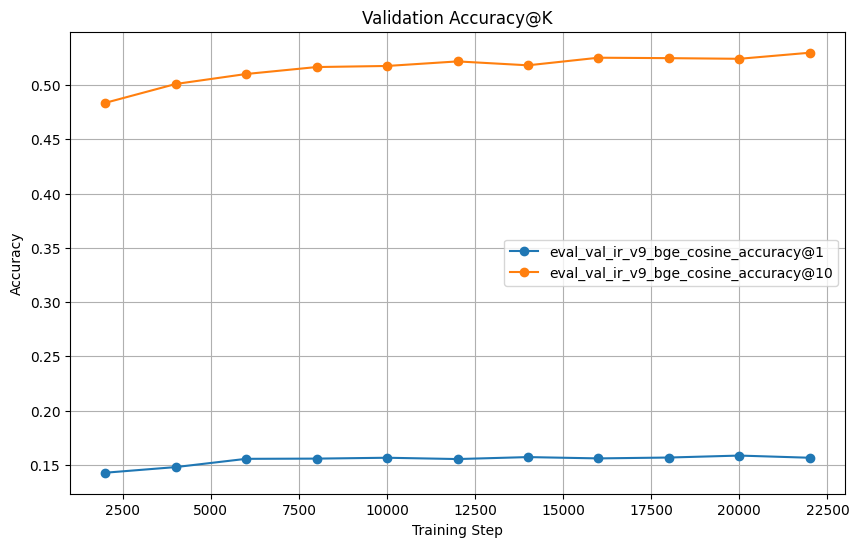

In [ ]:
accuracy_cols = [c for c in eval_log.columns if "accuracy@" in c.lower()]
print(accuracy_cols)

plt.figure(figsize=(10, 6))

for col in accuracy_cols:
    if col.endswith("@1") or col.endswith("@10"):
        plt.plot(eval_log["step"], eval_log[col], marker="o", label=col)

plt.xlabel("Training Step")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy@K")
plt.grid(True)
plt.legend()
plt.show()

<section dir="rtl" lang="ar" style="text-align: right;">
  <h3>14. رسم مقاييس الترتيب والاسترجاع أثناء التحقق</h3>
  <p>
    تقوم هذه الخلية باستخراج مقاييس الترتيب والاسترجاع المسجلة أثناء التحقق، مثل MRR وMAP وNDCG، ثم رسمها عبر خطوات التدريب. يوضح هذا الرسم مدى تحسن جودة ترتيب النتائج التي يعيدها النموذج، وليس فقط قدرته على الوصول إلى الإجابة الصحيحة.
  </p>
</section>

['eval_val_ir_v9_bge_cosine_map@100', 'eval_val_ir_v9_bge_cosine_mrr@10', 'eval_val_ir_v9_bge_cosine_ndcg@10']


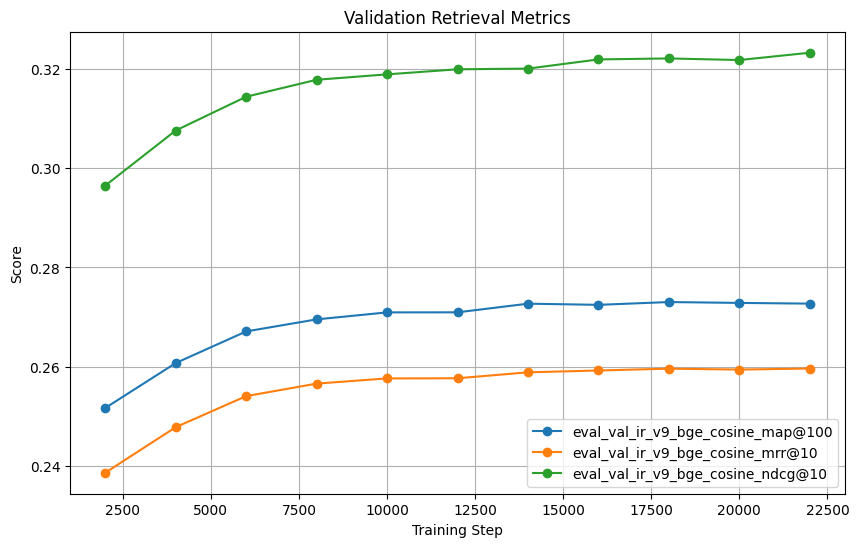

In [ ]:
ranking_cols = [
    c for c in eval_log.columns
    if "mrr@" in c.lower() or "map@" in c.lower() or "ndcg@" in c.lower()
]

print(ranking_cols)

plt.figure(figsize=(10, 6))

for col in ranking_cols:
    plt.plot(eval_log["step"], eval_log[col], marker="o", label=col)

plt.xlabel("Training Step")
plt.ylabel("Score")
plt.title("Validation Retrieval Metrics")
plt.grid(True)
plt.legend()
plt.show()

<section dir="rtl" lang="ar" style="text-align: right;">
  <h3>15. حفظ النسخة النهائية من النموذج</h3>
  <p>
    تقوم هذه الخلية بحفظ النموذج المدرّب في مجلد نهائي مخصص، ثم تتحقق من وجود المجلد بعد الحفظ. تهدف هذه الخطوة إلى تثبيت النسخة النهائية القابلة للاستخدام لاحقًا في التقييم أو التضمين داخل خط معالجة BERTopic.
  </p>
</section>

In [ ]:
FINAL_MODEL_DIR = OUTPUT_DIR / "final_model"

model.save_pretrained(str(FINAL_MODEL_DIR))

print("Saved final model:", FINAL_MODEL_DIR)
print("Exists:", FINAL_MODEL_DIR.exists())

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved final model: /content/drive/MyDrive/semester project/news_comment_topic_system/models/v9_bge_base_en_largepairs_1p5M_seq256/final_model
Exists: True


<section dir="rtl" lang="ar" style="text-align: right;">
  <h3>17. فحص جودة التمثيلات الدلالية بعد التدريب</h3>
  <p>
    تقوم هذه الخلية بتحميل النموذج المدرّب واختباره على عينة من أزواج التحقق، ثم تقارن بين تشابه الأزواج الصحيحة وتشابه أزواج عشوائية غير متطابقة. يهدف هذا الفحص إلى التأكد من أن النموذج يجعل التعليقات المتقاربة دلاليًا أقرب من التعليقات العشوائية، وأن التمثيلات الناتجة لم تنهَر إلى قيم متشابهة بشكل غير طبيعي.
  </p>
</section>

In [ ]:
from sentence_transformers import util

trained_model = SentenceTransformer(str(FINAL_MODEL_DIR), device=device)
trained_model.max_seq_length = MAX_SEQ_LENGTH

sample_pairs = val_pairs.sample(n=1000, random_state=RANDOM_STATE).reset_index(drop=True)

emb_a = trained_model.encode(
    sample_pairs["text_a"].tolist(),
    batch_size=128,
    convert_to_tensor=True,
    normalize_embeddings=True,
    show_progress_bar=True
)

emb_b = trained_model.encode(
    sample_pairs["text_b"].tolist(),
    batch_size=128,
    convert_to_tensor=True,
    normalize_embeddings=True,
    show_progress_bar=True
)

positive_scores = util.cos_sim(emb_a, emb_b).diagonal().detach().cpu().numpy()

random_b = sample_pairs["text_b"].sample(
    frac=1.0,
    random_state=RANDOM_STATE
).tolist()

emb_random_b = trained_model.encode(
    random_b,
    batch_size=128,
    convert_to_tensor=True,
    normalize_embeddings=True,
    show_progress_bar=True
)

random_scores = util.cos_sim(emb_a, emb_random_b).diagonal().detach().cpu().numpy()

print("Average positive-pair cosine:", round(float(np.mean(positive_scores)), 4))
print("Median positive-pair cosine:", round(float(np.median(positive_scores)), 4))
print("Average random-pair cosine:", round(float(np.mean(random_scores)), 4))
print("Median random-pair cosine:", round(float(np.median(random_scores)), 4))
print("Positive-Random Mean Gap:", round(float(np.mean(positive_scores) - np.mean(random_scores)), 4))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Average positive-pair cosine: 0.5579
Median positive-pair cosine: 0.5524
Average random-pair cosine: 0.0448
Median random-pair cosine: 0.026
Positive-Random Mean Gap: 0.5131


<section dir="rtl" lang="ar" style="text-align: right;">
  <h3>18. تحميل بيانات الاختبار وتجهيز النصوص للتقييم</h3>
  <p>
    تقوم هذه الخلية بتحميل مجموعة الاختبار النهائية، وتحديد العمود النصي المناسب، ثم تطبيق تنظيف نصي موحد يشمل إزالة الروابط، والبريد الإلكتروني، والأرقام، والرموز غير النصية. بعد ذلك تُنشئ نسخة جاهزة من التعليقات لاستخدامها في توليد التمثيلات الدلالية وتقييم النموذج داخل خط معالجة BERTopic.
  </p>
</section>

In [ ]:
TEST_POOL_PATH = PROJECT_ROOT / "evaluation_data/final_test_pool/test_large_clean_pool.csv"

if not TEST_POOL_PATH.exists():
    TEST_POOL_PATH = PROJECT_ROOT / "training_data/v5_clean_pools_20260420_194922/test_large_clean_pool.csv"

df = pd.read_csv(TEST_POOL_PATH)

TEXT_COL = "clean_text" if "clean_text" in df.columns else "message"

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " url ", text)
    text = re.sub(r"\S+@\S+", " email ", text)
    text = re.sub(r"\d+", " number ", text)
    text = re.sub(r"[^a-zA-Z\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["model_text"] = df[TEXT_COL].fillna("").astype(str).apply(clean_text)
df = df[df["model_text"].str.len() > 2].reset_index(drop=True)

docs = df["model_text"].tolist()

print("Test pool:", TEST_POOL_PATH)
print("Documents:", len(docs))

Test pool: /content/drive/MyDrive/semester project/news_comment_topic_system/evaluation_data/final_test_pool/test_large_clean_pool.csv
Documents: 58014


<section dir="rtl" lang="ar" style="text-align: right;">
  <h3>19. توليد التمثيلات الدلالية لتعليقات الاختبار</h3>
  <p>
    تقوم هذه الخلية بتحميل النموذج المدرّب واستخدامه لتحويل تعليقات الاختبار إلى تمثيلات رقمية دلالية. تُستخدم هذه التمثيلات لاحقًا داخل BERTopic بدل النص الخام، بحيث تعتمد عملية اكتشاف المواضيع على المعنى الدلالي للتعليقات لا على الكلمات السطحية فقط.
  </p>
</section>

In [ ]:
trained_model = SentenceTransformer(str(FINAL_MODEL_DIR), device=device)
trained_model.max_seq_length = MAX_SEQ_LENGTH

embeddings = trained_model.encode(
    docs,
    batch_size=128,
    normalize_embeddings=True,
    show_progress_bar=True
)

embeddings = np.asarray(embeddings)

print("Embeddings shape:", embeddings.shape)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/454 [00:00<?, ?it/s]

Embeddings shape: (58014, 768)


<section dir="rtl" lang="ar" style="text-align: right;">
  <h3>20. إعداد BERTopic واستخراج المواضيع من التعليقات</h3>
  <p>
    تقوم هذه الخلية بإنشاء نموذج BERTopic باستخدام التمثيلات الدلالية المحسوبة مسبقًا، مع ضبط مكوّنات تقليل الأبعاد، والتجميع، واستخراج الكلمات المفتاحية. بعد ذلك يتم تدريب النموذج على تعليقات الاختبار لاكتشاف المواضيع تلقائيًا، مع حساب عدد المواضيع المكتشفة وعدد التعليقات المصنفة كضجيج.
  </p>
</section>

In [ ]:
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords", quiet=True)

umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

hdbscan_model = HDBSCAN(
    min_cluster_size=100,
    min_samples=10,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

vectorizer_model = CountVectorizer(
    stop_words=stopwords.words("english"),
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.7
)

topic_model = BERTopic(
    embedding_model=None,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    top_n_words=10,
    calculate_probabilities=True,
    verbose=True
)

topics, probs = topic_model.fit_transform(docs, embeddings)

print("Done.")
print("Documents:", len(docs))
print("Unique topics including -1:", len(set(topics)))
print("Unique valid topics:", len(set(t for t in topics if t != -1)))

2026-05-04 23:33:06,175 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-04 23:33:40,762 - BERTopic - Dimensionality - Completed ✓
2026-05-04 23:33:40,764 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-04 23:33:59,371 - BERTopic - Cluster - Completed ✓
2026-05-04 23:33:59,377 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-04 23:34:00,565 - BERTopic - Representation - Completed ✓


Done.
Documents: 58014
Unique topics including -1: 117
Unique valid topics: 116


<section dir="rtl" lang="ar" style="text-align: right;">
  <h3>21. حساب مقاييس تقييم المواضيع النهائية</h3>
  <p>
    تقوم هذه الخلية بحساب المقاييس الأساسية الناتجة عن نموذج BERTopic، وتشمل عدد التعليقات الكلي، وعدد التعليقات المرتبطة بمواضيع صالحة، وعدد تعليقات الضجيج، ونسبتها، وعدد المواضيع المكتشفة، إضافة إلى متوسط الثقة وتنوع الكلمات المفتاحية داخل المواضيع. تساعد هذه المقاييس على تقييم جودة اكتشاف المواضيع بشكل كمي بعد انتهاء عملية التجميع.
  </p>
</section>

In [ ]:
topics_arr = np.array(topics)

total_docs = len(topics_arr)
noise_comments = int((topics_arr == -1).sum())
valid_comments = total_docs - noise_comments

noise_ratio = noise_comments / total_docs * 100
valid_ratio = valid_comments / total_docs * 100
detected_topics = len(set(t for t in topics_arr if t != -1))

if probs is None:
    conf = np.full(total_docs, np.nan)
else:
    probs_arr = np.asarray(probs)
    if probs_arr.ndim == 1:
        conf = probs_arr
    else:
        conf = probs_arr.max(axis=1)

avg_conf_all = float(np.nanmean(conf))
avg_conf_valid = float(np.nanmean(conf[topics_arr != -1]))
median_conf_valid = float(np.nanmedian(conf[topics_arr != -1]))

def topic_diversity(topic_model, top_n=10):
    words = []
    for topic_id in topic_model.get_topics():
        if topic_id == -1:
            continue
        topic_words = topic_model.get_topic(topic_id)
        if topic_words:
            words.extend([w for w, s in topic_words[:top_n]])
    return len(set(words)) / len(words)

diversity = topic_diversity(topic_model, top_n=10)

metrics = {
    "Model": "V9 BGE Base English LargePairs",
    "Total Documents": total_docs,
    "Valid Topic Comments": valid_comments,
    "Noise Comments": noise_comments,
    "Valid Ratio": round(valid_ratio, 2),
    "Noise Ratio": round(noise_ratio, 2),
    "Detected Topics": detected_topics,
    "Average Confidence All": round(avg_conf_all * 100, 2),
    "Average Confidence Valid": round(avg_conf_valid * 100, 2),
    "Median Confidence Valid": round(median_conf_valid * 100, 2),
    "Topic Diversity": round(diversity, 4),
}

metrics_df = pd.DataFrame([metrics])
display(metrics_df)

,Model,Total Documents,Valid Topic Comments,Noise Comments,Valid Ratio,Noise Ratio,Detected Topics,Average Confidence All,Average Confidence Valid,Median Confidence Valid,Topic Diversity
0,V9 BGE Base English LargePairs,58014,37581,20433,64.78,35.22,116,33.66,50.04,32.91,0.8784


<section dir="rtl" lang="ar" style="text-align: right;">
  <h3>22. مقارنة نتائج النموذج المعتمد مع النموذج التجريبي</h3>
  <p>
    تقوم هذه الخلية بتحميل مقاييس النموذج المعتمد سابقًا ومقارنتها مع مقاييس النموذج التجريبي الحالي، ثم تعرض المقارنة وفق المقاييس الأساسية نفسها، مثل عدد التعليقات الصالحة، نسبة الضجيج، عدد المواضيع، متوسط الثقة، وتنوع المواضيع. تساعد هذه المقارنة على تحديد ما إذا كان النموذج الجديد يقدم تحسنًا فعليًا داخل BERTopic أم لا.
  </p>
</section>

In [ ]:
v7_metrics_path = (
    PROJECT_ROOT
    / "bertopic_experiments_clean"
    / "v7_fullft_minilm_raw_largepairs_1p5M_seq256"
    / "v7_seq256_umap15_mcs100_ms10"
    / "metrics_v7_seq256_umap15_mcs100_ms10.csv"
)

v7_metrics = pd.read_csv(v7_metrics_path)

v7_row = v7_metrics.iloc[0].copy()
v9_row = metrics_df.iloc[0].copy()

v7_row["Model"] = "V7 Final"
v9_row["Model"] = "V9 BGE"

comparison = pd.DataFrame([v7_row, v9_row])

cols = [
    "Model",
    "Total Documents",
    "Valid Topic Comments",
    "Noise Comments",
    "Valid Ratio",
    "Noise Ratio",
    "Detected Topics",
    "Average Confidence All",
    "Average Confidence Valid",
    "Median Confidence Valid",
    "Topic Diversity"
]

available_cols = [c for c in cols if c in comparison.columns]

display(comparison[available_cols].T)

,0,0
Model,V7 Final,V9 BGE
Total Documents,58014,58014
Valid Topic Comments,39458,37581
Noise Comments,18556,20433
Valid Ratio,68.01,64.78
Noise Ratio,31.99,35.22
Detected Topics,94,116
Average Confidence All,56.13,33.66
Average Confidence Valid,82.52,50.04
Median Confidence Valid,98.08,32.91
